# Workshop 1 — Machine Learning
### Análisis Exploratorio de Datos (EDA) — Anime Recommendations Database

Este notebook desarrolla el ciclo completo de EDA (reconocimiento, limpieza, análisis descriptivo y visualización) sobre el dataset de Kaggle **Anime Recommendations Database**, que trae la info de 12,294 animes listados en MyAnimeList (nombre, género, tipo, episodios, rating y cantidad de miembros que lo siguen).

In [32]:
# Bloque 1: Importar librerías y cargar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('anime.csv')
print(df.shape)
df.head()

Saving anime.csv to anime (2).csv
(12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [33]:
# Primeras y últimas 5 filas
print(df.head())
print(df.tail())

print("Filas y columnas:", df.shape)

   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
       anime_id                                               name   genre  \
12289      9316       Toushindai My Lover: Minami tai Mecha-Minami  

## Fase 1 — Reconocimiento inicial

El dataset que nos tocó es sobre animes: básicamente tiene el catálogo completo de MyAnimeList con info de cada uno (género, tipo, cuántos episodios tiene, qué tan bien calificado está y cuánta gente lo sigue). La idea es entender qué hace que un anime sea popular o bien calificado, que puede servir después para un modelo que prediga esto.

**Diccionario de datos:**

| Columna | Tipo esperado | Qué significa |
|---|---|---|
| anime_id | numérico (int) | ID único del anime |
| name | texto | Nombre del anime |
| genre | texto (varios géneros separados por coma) | Géneros a los que pertenece |
| type | categórica | TV, Movie, OVA, Special, ONA o Music |
| episodes | numérico | Cantidad de episodios |
| rating | numérico (float) | Calificación promedio que le dieron los usuarios (0-10) |
| members | numérico (int) | Cuántos usuarios lo tienen agregado a su lista |

Con el `.shape` vemos que son 12,294 filas y 7 columnas.

In [34]:
df.info()
print("\nTipos de datos:\n", df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB

Tipos de datos:
 anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object


In [35]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


Mirando el `.describe()`, hay tres cosas que nos parecieron importantes:

- El `rating` promedio es de 6.47 con una desviación de apenas 1.03, o sea que la mayoría de los animes se mueven en un rango bastante cerrado (como entre 5.4 y 7.5). El mínimo es 1.67, así que tampoco hay animes con calificación horrible.
- En `members` la cosa cambia total: la media es 18,071 pero la desviación estándar es 54,818, o sea casi 3 veces más grande que la media. Eso ya nos dice que la variable está bien sesgada, seguramente por unos pocos animes súper populares que se salen del montón (esto lo confirmamos más adelante con el IQR).
- Varias columnas tienen menos de 12,294 en el conteo (`genre`, `type`, `rating`), lo que quiere decir que ahí hay nulos que toca revisar en la limpieza.

In [36]:
# Usamos 'members' como ejemplo (rating también podría servir, pero members no tiene nulos)
members_array = df['members'].to_numpy()

print("Media (NumPy):", np.mean(members_array))
print("Mediana (NumPy):", np.median(members_array))
print("Desv. estándar (NumPy):", np.std(members_array))

Media (NumPy): 18071.33886448674
Mediana (NumPy): 1550.0
Desv. estándar (NumPy): 54818.44730916939


Calculamos a mano con NumPy la media, mediana y desviación de `members` para comprobar que da lo mismo que si lo hubiéramos hecho con pandas (`.mean()`, `.median()`, `.std()`). La mediana (1550) es muchísimo más baja que la media (18,071), lo que refuerza lo que decíamos arriba: hay pocos animes con demasiados members que "jalan" el promedio para arriba.

## Fase 2 — Limpieza de datos

In [37]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje_%': porcentaje_nulos.round(2)})
print(resumen_nulos[resumen_nulos['nulos'] > 0])

        nulos  porcentaje_%
genre      62          0.50
type       25          0.20
rating    230          1.87


In [38]:
# "Unknown" -> NaN, y luego convertir a numérico
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

# ¿Cuántos "Unknown" (ahora NaN) había?
print("Nulos en episodes tras conversión:", df['episodes'].isnull().sum())
df['episodes'].describe()

Nulos en episodes tras conversión: 340


,episodes
count,11954.000000
mean,12.382550
std,46.865352
min,1.000000
25%,1.000000
50%,2.000000
75%,12.000000
max,1818.000000


Encontramos nulos en `genre` (62, 0.5%), `type` (25, 0.2%) y `rating` (230, 1.87%). Además, `episodes` venía como texto porque tenía la palabra "Unknown" en vez de un número — al convertirlo a numérico, esos "Unknown" se volvieron 340 nulos (2.77%).

Con esto decidimos qué hacer con cada uno:

- **genre**: como son pocos nulos (0.5%), los rellenamos con la palabra "Unknown" en vez de borrar la fila, para no perder el resto de info de esos animes (rating, members, etc).
- **episodes**: lo rellenamos con la **mediana** (no la media) porque esta columna tiene outliers extremos (hay animes con más de 1800 episodios), entonces la media queda inflada y no representa bien al "anime típico".
- **type** y **rating**: estos sí los eliminamos. No tiene sentido inventarnos de qué tipo es un anime o qué rating tiene — sería literalmente inventar el dato. Como son pocas filas (menos del 2%), no afecta el análisis.

In [39]:
# 1. genre -> imputar "Unknown"
df['genre'] = df['genre'].fillna('Unknown')

# 2. episodes -> imputar con mediana
mediana_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(mediana_episodes)
print("Mediana usada para episodes:", mediana_episodes)

# 3. type y rating -> eliminar filas (no tiene sentido inventar el valor)
filas_antes = df.shape[0]
df = df.dropna(subset=['type', 'rating'])
filas_despues = df.shape[0]
print(f"Filas eliminadas por nulos en type/rating: {filas_antes - filas_despues}")

# Verificación final
print("\nNulos restantes:\n", df.isnull().sum())
print("Shape final:", df.shape)

Mediana usada para episodes: 2.0
Filas eliminadas por nulos en type/rating: 230

Nulos restantes:
 anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64
Shape final: (12064, 7)


Al final quedamos con 12,064 filas y cero nulos. Ojo con un detalle: eliminamos 230 filas en total, no 255 (que sería 230+25), lo que nos dice que los 25 registros sin `type` probablemente ya estaban incluidos dentro de los 230 que tampoco tenían `rating`.

In [40]:
duplicados = df.duplicated().sum()
print("Filas duplicadas encontradas:", duplicados)

df = df.drop_duplicates()
print("Shape después de eliminar duplicados:", df.shape)

Filas duplicadas encontradas: 0
Shape después de eliminar duplicados: (12064, 7)


No encontramos ninguna fila duplicada (0), así que no hubo que quitar nada acá. La verdad no lo esperábamos, uno siempre piensa que en Kaggle los datasets vienen con basura, pero este en particular no tenía duplicados.

In [41]:
# Revisamos las columnas categóricas de texto
print("Valores únicos en 'type':")
print(df['type'].unique())

print("\nPrimeros 20 valores únicos en 'genre' (es una lista libre, revisamos formato):")
print(df['genre'].unique()[:20])

# Buscamos espacios extra o inconsistencias de mayúsculas/minúsculas
print("\n¿Hay espacios extra en 'type'?")
for t in df['type'].unique():
    print(repr(t))

Valores únicos en 'type':
['Movie' 'TV' 'OVA' 'Special' 'Music' 'ONA']

Primeros 20 valores únicos en 'genre' (es una lista libre, revisamos formato):
['Drama, Romance, School, Supernatural'
 'Action, Adventure, Drama, Fantasy, Magic, Military, Shounen'
 'Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen'
 'Sci-Fi, Thriller' 'Comedy, Drama, School, Shounen, Sports'
 'Action, Adventure, Shounen, Super Power'
 'Drama, Military, Sci-Fi, Space'
 'Drama, Fantasy, Romance, Slice of Life, Supernatural'
 'Drama, School, Shounen'
 'Action, Drama, Mecha, Military, Sci-Fi, Super Power'
 'Adventure, Drama, Supernatural' 'Drama, Music, Romance, School, Shounen'
 'Adventure, Fantasy, Historical, Mystery, Seinen, Slice of Life, Supernatural'
 'Fantasy, Slice of Life'
 'Action, Mecha, Military, School, Sci-Fi, Super Power'
 'Comedy, Drama, Shounen, Sports'
 'Action, Drama, Historical, Martial Arts, Romance, Samurai'
 'Action, Adventure, Comedy, Drama, Sci-Fi, Space'
 'Action, Comedy, Parody

Revisamos `type` y no encontramos ningún problema de formato (nada de "tv" en minúscula o con espacios de más, quedó limpio: Movie, TV, OVA, Special, Music, ONA). En `genre` tampoco vimos nada raro en el formato, aunque como es una columna de texto libre con varios géneros por fila, más adelante la separamos por comas para poder analizar género por género individual.

In [42]:
# Ejemplo con 'members' (variable con fuerte asimetría, como vimos en describe())
Q1 = df['members'].quantile(0.25)
Q3 = df['members'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['members'] < limite_inferior) | (df['members'] > limite_superior)]
print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Límites: [{limite_inferior}, {limite_superior}]")
print(f"Cantidad de outliers en 'members': {outliers.shape[0]} ({outliers.shape[0]/df.shape[0]*100:.2f}%)")

outliers[['name', 'members', 'rating']].sort_values('members', ascending=False).head(10)

Q1=221.0, Q3=9485.5, IQR=9264.5
Límites: [-13675.75, 23382.25]
Cantidad de outliers en 'members': 1884 (15.62%)


,name,members,rating
40,Death Note,1013917,8.71
86,Shingeki no Kyojin,896229,8.54
804,Sword Art Online,893100,7.83
1,Fullmetal Alchemist: Brotherhood,793665,9.26
159,Angel Beats!,717796,8.39
19,Code Geass: Hangyaku no Lelouch,715151,8.83
841,Naruto,683297,7.81
3,Steins;Gate,673572,9.17
445,Mirai Nikki (TV),657190,8.07
131,Toradora!,633817,8.45


Usando el rango intercuartílico en `members`, el límite superior nos dio en 23,382. Todo lo que esté por encima de eso lo consideramos outlier, y salieron **1,884 animes (15.62%)** en esa condición. Tiene mucho sentido revisar quiénes son: en el top 10 aparecen animes como Death Note, Shingeki no Kyojin, Sword Art Online, Fullmetal Alchemist: Brotherhood, todos animes bien mainstream que casi cualquiera conoce. No los eliminamos porque no son un error de datos, son simplemente los animes más populares del catálogo — eliminarlos sería perder información real y valiosa.

## Fase 3 — Exploración y análisis descriptivo

In [43]:
print("Conteo por 'type':")
print(df['type'].value_counts())

# 'genre' es una lista libre (multi-valor); la separamos para contar géneros individuales
generos_individuales = df['genre'].str.split(', ').explode()
print("\nTop 15 géneros individuales más frecuentes:")
print(generos_individuales.value_counts().head(15))

Conteo por 'type':
type
TV         3671
OVA        3285
Movie      2297
Special    1671
ONA         652
Music       488
Name: count, dtype: int64

Top 15 géneros individuales más frecuentes:
genre
Comedy           4575
Action           2768
Adventure        2316
Fantasy          2242
Sci-Fi           2036
Drama            1977
Shounen          1684
Kids             1598
Romance          1437
Slice of Life    1204
School           1176
Hentai           1133
Supernatural     1001
Mecha             929
Music             842
Name: count, dtype: int64


Por `type`, la mayoría del catálogo es TV (3,671) y OVA (3,285), y lo que menos hay es Music (488). Separando los géneros individuales (porque en la columna original vienen varios géneros juntos por anime), el más común de lejos es Comedy (4,575), seguido de Action (2,768) y Adventure (2,316).

In [44]:
# Para cada 'type', calculamos el rating promedio SOLO de ese subconjunto
rating_promedio_por_type = {}

for t in df['type'].unique():
    subset = df[df['type'] == t]
    rating_promedio_por_type[t] = round(subset['rating'].mean(), 2)

print(rating_promedio_por_type)

{'Movie': np.float64(6.32), 'TV': np.float64(6.9), 'OVA': np.float64(6.38), 'Special': np.float64(6.52), 'Music': np.float64(5.59), 'ONA': np.float64(5.64)}


In [45]:
# Pregunta 1: ¿cuál tipo de anime (TV, Movie, OVA...) tiene mejor rating promedio y más miembros?
pregunta1 = df.groupby('type')[['rating', 'members']].mean().sort_values('rating', ascending=False)
print("Pregunta 1: Rating y members promedio por tipo\n", pregunta1)

# Pregunta 2: ¿el número de episodios se relaciona con más popularidad (members) según el tipo?
pregunta2 = df.groupby('type')['episodes'].agg(['mean', 'median', 'max'])
print("\nPregunta 2: Episodios promedio/mediana/máximo por tipo\n", pregunta2)

Pregunta 1: Rating y members promedio por tipo
            rating       members
type                           
TV       6.902299  43774.971670
Special  6.523501   7691.870138
OVA      6.375221   6013.899543
Movie    6.318058  10392.398346
ONA      5.643298   4150.253067
Music    5.588996   1311.840164

Pregunta 2: Episodios promedio/mediana/máximo por tipo
               mean  median     max
type                              
Movie     1.104919     1.0   100.0
Music     1.133197     1.0    24.0
ONA       6.549080     2.0    84.0
OVA       2.417352     2.0   110.0
Special   2.564333     1.0    51.0
TV       35.034868    24.0  1818.0


Con el groupby por `type` respondimos dos preguntas:

1. **¿Qué tipo tiene mejor rating y más members?** TV gana en las dos: rating promedio de 6.90 y casi 43,775 members promedio, muy por encima de los demás tipos (el segundo lugar en members, Movie, ni siquiera llega a 10,400). Tiene sentido: una serie de TV se ve durante varias semanas/temporadas, entonces tiene más tiempo para acumular seguidores que una película que se ve una sola vez.
2. **¿Cómo varían los episodios según el tipo?** Ahí salió algo raro: Movie tiene un máximo de 100 episodios, cuando uno esperaría que las películas fueran de 1 solo episodio (la mediana sí es 1). Puede ser un error en cómo se etiquetó ese dato en el dataset original, o quizás sea alguna compilación categorizada como "Movie". Vale la pena mencionarlo como un hallazgo raro, no lo investigamos más a fondo pero quedó anotado.

In [46]:
print("Top 5 animes con más miembros (más populares):")
print(df.sort_values('members', ascending=False)[['name', 'type', 'rating', 'members']].head(5))

print("\nBottom 5 animes con menos miembros (menos populares):")
print(df.sort_values('members', ascending=True)[['name', 'type', 'rating', 'members']].head(5))

Top 5 animes con más miembros (más populares):
                                 name type  rating  members
40                         Death Note   TV    8.71  1013917
86                 Shingeki no Kyojin   TV    8.54   896229
804                  Sword Art Online   TV    7.83   893100
1    Fullmetal Alchemist: Brotherhood   TV    9.26   793665
159                      Angel Beats!   TV    8.39   717796

Bottom 5 animes con menos miembros (menos populares):
                                          name   type  rating  members
10444                           Sushi Azarashi     TV     3.0       12
10424                            Suijun Genten  Movie     7.0       13
10464  Taka no Tsume 8: Yoshida-kun no X-Files  Movie    10.0       13
10719                         Wareware no Heya  Movie     8.0       15
8367       Chotto Ugoku!? &quot;Futeneko&quot;    OVA     6.0       17


En el top 5 por `members` aparecen puros animes de tipo TV (Death Note, Shingeki no Kyojin, Sword Art Online, FMA: Brotherhood, Angel Beats!), lo cual confirma otra vez que TV es el formato que más engancha.

En el bottom 5 nos encontramos un caso curioso: *Taka no Tsume 8* tiene rating de 10.0 (perfecto) pero solo 13 members. O sea, prácticamente nadie lo vio, y probablemente lo calificaron 1 o 2 personas que le dieron 10 sin más. Esto nos hizo pensar que un rating "perfecto" no siempre es confiable si no está respaldado por muchos votos.

## Fase 4 — Visualización

**Barras (distribución por type):** Se nota clarísimo que TV y OVA son los tipos más comunes en el catálogo, mientras que Music casi no tiene representación. Como recomendación, si alguien quisiera armar un catálogo o una plataforma de recomendación, tendría sentido enfocar el catálogo principal en TV, ya que además de ser el más numeroso es el que mejor rating y más popularidad tiene (como vimos en la Fase 3).

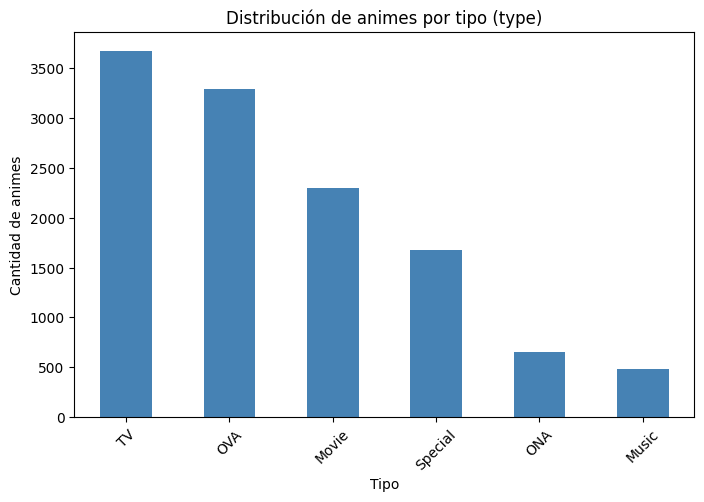

In [47]:
plt.figure(figsize=(8,5))
df['type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución de animes por tipo (type)')
plt.xlabel('Tipo')
plt.ylabel('Cantidad de animes')
plt.xticks(rotation=45)
plt.show()

**Pie (outliers en members):**

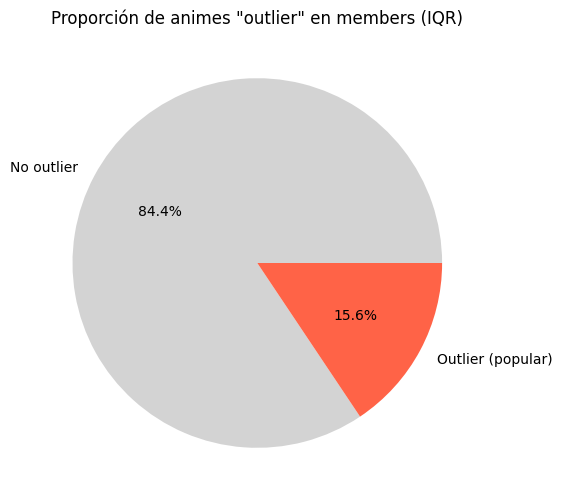

In [48]:
# Reutilizamos el criterio IQR del punto 11
Q1 = df['members'].quantile(0.25)
Q3 = df['members'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df['es_outlier_members'] = df['members'] > limite_superior

conteo = df['es_outlier_members'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(conteo, labels=['No outlier', 'Outlier (popular)'], autopct='%1.1f%%', colors=['lightgray','tomato'])
plt.title('Proporción de animes "outlier" en members (IQR)')
plt.show()

El 15.6% de los animes son outliers de popularidad, coincide justo con lo que habíamos calculado a mano en la Fase 2 (15.62%). En términos de negocio, esto nos dice que casi toda la atención de la comunidad se concentra en un grupo chiquito de animes "top", mientras que el 84% restante son animes de nicho que casi nadie ve. **Recomendación:** si uno tuviera que invertir en promoción, tendría más sentido enfocarse en ese 15% que ya tiene tracción, en vez de repartir esfuerzo parejo entre todos.

**Histograma (distribución de rating):**

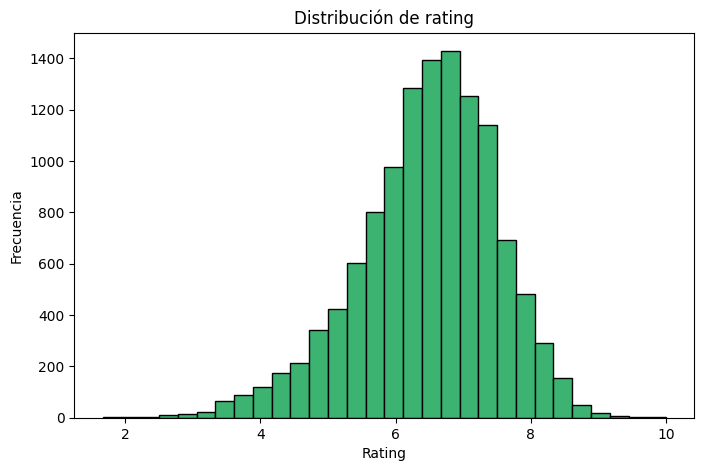

In [49]:
plt.figure(figsize=(8,5))
plt.hist(df['rating'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribución de rating')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.show()

La forma es más o menos una campana, pero con una colita un poco más larga hacia la izquierda (hacia los ratings bajos), o sea que hay más animes "mediocres" que animes "malísimos". La mayoría se concentra entre 5.5 y 8, que es justo donde vive el "anime promedio".

**Scatter (rating vs members):**

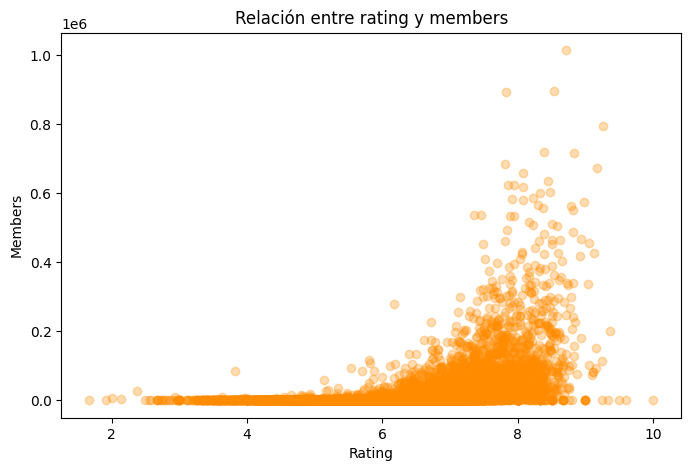

Correlación: 0.3879794585003166


In [50]:
plt.figure(figsize=(8,5))
plt.scatter(df['rating'], df['members'], alpha=0.3, color='darkorange')
plt.title('Relación entre rating y members')
plt.xlabel('Rating')
plt.ylabel('Members')
plt.show()

print("Correlación:", df['rating'].corr(df['members']))

La correlación nos dio 0.39, que es positiva pero no muy fuerte. Viendo el gráfico, se nota que casi ningún anime con rating bajo tiene muchos members, pero entre los de rating alto hay de todo: algunos con pocos members y otros con muchísimos. O sea, tener buen rating parece ser casi un requisito para ser popular, pero no lo garantiza — hay otros factores de por medio (como qué tan viejo es el anime, cuánto se promocionó, etc).

**Boxplot de members:**

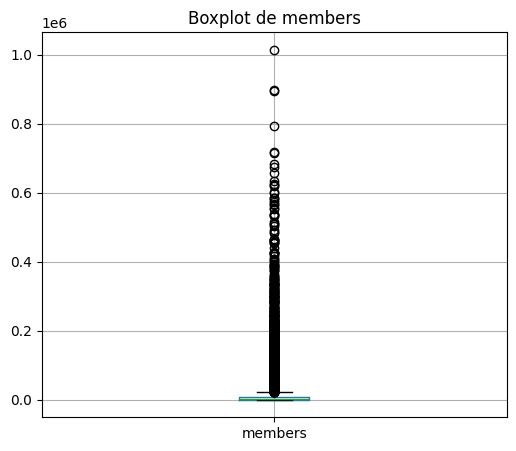

In [51]:
plt.figure(figsize=(6,5))
df.boxplot(column='members')
plt.title('Boxplot de members')
plt.show()

Se ve clarísimo lo que ya sabíamos: la caja queda pegada casi al piso (porque la mayoría de animes tienen pocos members) y hay una nube enorme de puntos por encima que son los outliers. Esto es exactamente lo mismo que encontramos con el criterio de IQR en la Fase 2 (15.62%), solo que acá se ve de forma visual.

**Boxplot comparativo (rating por type):**

<Figure size 900x500 with 0 Axes>

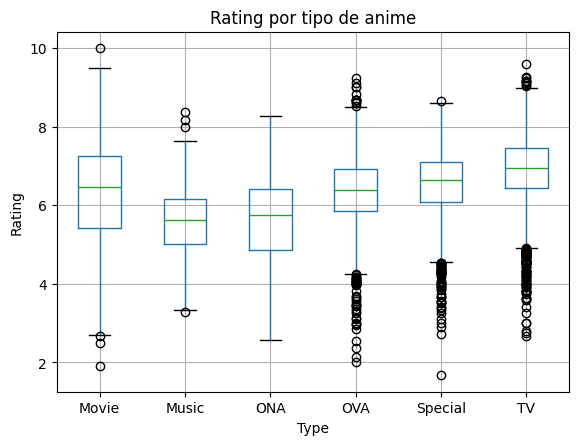

In [52]:
plt.figure(figsize=(9,5))
df.boxplot(column='rating', by='type')
plt.title('Rating por tipo de anime')
plt.suptitle('')
plt.xlabel('Type')
plt.ylabel('Rating')
plt.show()

TV tiene la mediana más alta de todos los tipos, lo cual confirma otra vez lo que vimos con el groupby. Pero ojo, TV también es el que más outliers hacia abajo tiene (hay bastantes animes tipo TV con rating bajo), así que no todo lo que es TV es necesariamente bueno, solo que en promedio le va mejor que a los demás tipos. ONA es el que tiene la caja más ancha, o sea el más inconsistente en calidad.

## Fase 5 — Conclusiones

Para cerrar, armamos un resumen visual con las 4 gráficas que mejor explican los hallazgos principales: la distribución por tipo, la proporción de outliers, la distribución del rating y cómo varía el rating según el tipo de anime.

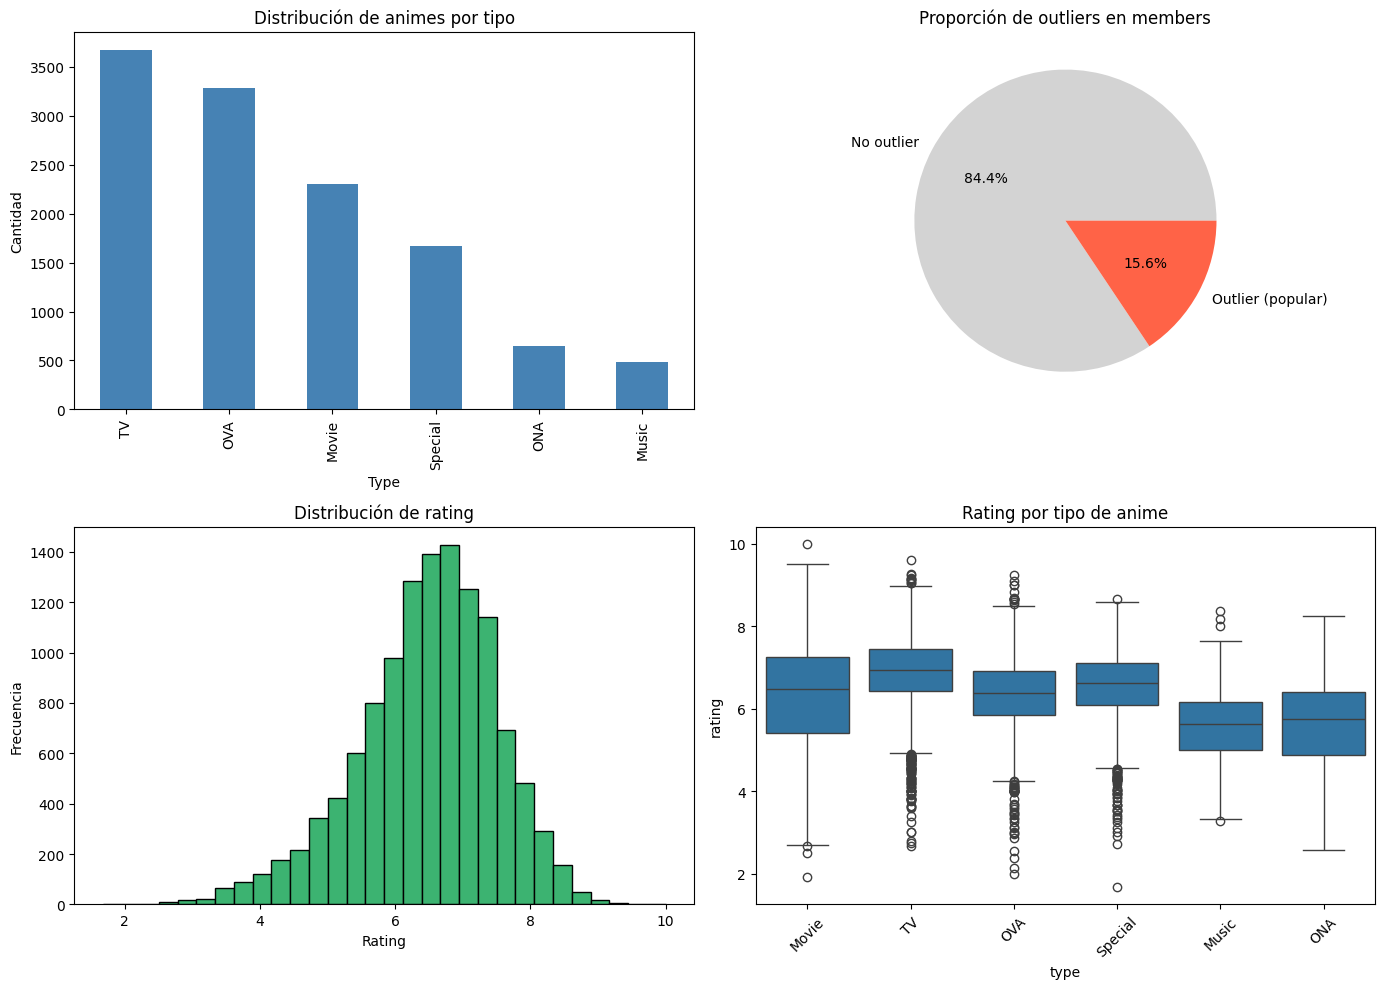

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1. Barras: distribución por type
df['type'].value_counts().plot(kind='bar', color='steelblue', ax=axes[0,0])
axes[0,0].set_title('Distribución de animes por tipo')
axes[0,0].set_xlabel('Type')
axes[0,0].set_ylabel('Cantidad')

# 2. Pie: outliers en members
conteo = df['es_outlier_members'].value_counts()
axes[0,1].pie(conteo, labels=['No outlier','Outlier (popular)'], autopct='%1.1f%%', colors=['lightgray','tomato'])
axes[0,1].set_title('Proporción de outliers en members')

# 3. Histograma: rating
axes[1,0].hist(df['rating'], bins=30, color='mediumseagreen', edgecolor='black')
axes[1,0].set_title('Distribución de rating')
axes[1,0].set_xlabel('Rating')
axes[1,0].set_ylabel('Frecuencia')

# 4. Boxplot: rating por type
sns.boxplot(x='type', y='rating', data=df, ax=axes[1,1])
axes[1,1].set_title('Rating por tipo de anime')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Conclusiones

Con este dataset nos dimos cuenta de que la mayoría de los animes en el catálogo son de tipo TV y OVA, y que justamente el tipo TV es el que mejor le va tanto en rating (6.90 en promedio) como en popularidad (casi 44 mil members en promedio, muy por encima de los demás). También notamos que members está bastante desbalanceada: solo un 15.6% de los animes concentra casi toda la popularidad, mientras que el resto del catálogo son animes de nicho con pocos seguidores. El rating, en cambio, sí se comporta más "normal", aunque con una colita hacia la izquierda (hay más animes medio-malos que animes extremadamente buenos).

Para la limpieza no tocó hacer mucho: quitamos las filas sin type o sin rating porque no tenía sentido inventarnos esos datos (eran menos del 2% del total, así que no afectó mucho), y en genre y episodes sí imputamos porque eran pocos nulos y perder esas filas era un desperdicio de información. No encontramos duplicados ni texto mal escrito, cosa que no esperábamos porque uno siempre espera que un dataset de Kaggle tenga algo sucio.

Lo que más nos llamó la atención fue que el rating y el members no están tan correlacionados como uno pensaría (0.39, o sea una relación débil-moderada), lo que nos hace pensar que un anime puede ser muy bueno sin ser masivamente popular, y viceversa. Además encontramos un caso raro: un anime con rating de 10.0 pero apenas 13 members, lo que nos parece más un caso de "pocas personas lo vieron y lo amaron" que un rating confiable.

Para un futuro modelo de Machine Learning nos quedan varias preguntas abiertas: ¿se podría predecir el rating de un anime solo con su género y tipo? ¿cómo se le pondría un peso al rating para que los animes con pocos votos no distorsionen tanto el análisis? ¿hay géneros específicos que casi siempre se asocien con mejor recepción?